In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

print("Everything is working!")

Matplotlib is building the font cache; this may take a moment.


Everything is working!


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


In [3]:
df = pd.read_csv("../data/raw/ballistic_v50.csv")

In [4]:
df.head()

,projectile,proj_type,calibre,proj_mass,proj_density,proj_hardness,Material,thickness,density,modulus,hardness,yield,PR,UTS,elongation,Ludwik-n,angle,v50,sigma_mps,ind_data,source
0,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6070-O,20,2.71,70.0,35,70.0,0.33,145.0,20.0,0.175,0,348,NaN,Y,forrestal_21_jdbm
1,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6070-T4,20,2.71,70.0,90,170.0,0.33,320.0,20.0,0.192,0,506,NaN,Y,forrestal_21_jdbm
2,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6082-T6,10,2.70,70.0,90,260.0,0.33,290.0,10.0,0.070,0,347,NaN,N,forrestal_21_jdbm
3,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6082-T6,20,2.70,70.0,90,260.0,0.33,290.0,10.0,0.070,0,501,NaN,Y,forrestal_14_expmech
4,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6082-T6,20,2.70,70.0,90,260.0,0.33,290.0,10.0,0.070,15,516,NaN,Y,forrestal_14_expmech


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1084
Columns: 21


In [6]:
df.columns

Index(['projectile', 'proj_type', 'calibre', 'proj_mass', 'proj_density',
       'proj_hardness', 'Material', 'thickness', 'density', 'modulus',
       'hardness', 'yield', 'PR', 'UTS', 'elongation', 'Ludwik-n', 'angle',
       'v50', 'sigma_mps', 'ind_data', 'source'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1084 entries, 0 to 1083
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   projectile     1084 non-null   str    
 1   proj_type      1084 non-null   str    
 2   calibre        1084 non-null   float64
 3   proj_mass      1084 non-null   float64
 4   proj_density   1084 non-null   float64
 5   proj_hardness  1084 non-null   int64  
 6   Material       1084 non-null   str    
 7   thickness      1084 non-null   str    
 8   density        1084 non-null   float64
 9   modulus        1084 non-null   float64
 10  hardness       1084 non-null   str    
 11  yield          1084 non-null   float64
 12  PR             1084 non-null   float64
 13  UTS            1084 non-null   float64
 14  elongation     1084 non-null   float64
 15  Ludwik-n       1084 non-null   float64
 16  angle          1084 non-null   str    
 17  v50            1084 non-null   str    
 18  sigma_mps      525 

In [8]:
df.describe()

,calibre,proj_mass,proj_density,proj_hardness,density,modulus,yield,PR,UTS,elongation,Ludwik-n
count,1084.000000,1084.00000,1084.000000,1084.000000,1084.000000,1084.000000,1084.000000,1084.000000,1084.000000,1084.000000,1084.000000
mean,9.450363,20.54294,8.714668,538.316421,4.457463,115.714520,679.061934,0.319899,836.391119,12.068509,0.087455
std,4.122990,26.13028,2.334369,151.473753,2.418799,65.047561,500.394069,0.014184,646.046109,3.603060,0.029233
min,6.248400,5.30000,7.850000,24.000000,2.660000,67.600000,70.000000,0.300000,145.000000,6.000000,0.037400
25%,6.248400,5.30000,7.850000,570.000000,2.700000,68.300000,276.000000,0.300000,310.000000,9.000000,0.066000
50%,6.248400,5.30000,7.850000,570.000000,2.760000,70.900000,400.000000,0.330000,469.000000,11.093900,0.071200
75%,10.922000,25.90000,7.850000,630.000000,7.850000,207.000000,1305.000000,0.330000,1690.000000,17.000000,0.117500
max,19.900000,212.00000,18.000000,730.000000,7.850000,207.000000,2094.410000,0.330000,2250.000000,20.000000,0.192000


In [10]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

sigma_mps        559
proj_type          0
calibre            0
proj_mass          0
projectile         0
proj_density       0
proj_hardness      0
thickness          0
Material           0
modulus            0
hardness           0
yield              0
density            0
PR                 0
UTS                0
Ludwik-n           0
elongation         0
angle              0
v50                0
ind_data           0
source             0
dtype: int64

In [11]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

sigma_mps        51.568266
proj_type         0.000000
calibre           0.000000
proj_mass         0.000000
projectile        0.000000
proj_density      0.000000
proj_hardness     0.000000
thickness         0.000000
Material          0.000000
modulus           0.000000
hardness          0.000000
yield             0.000000
density           0.000000
PR                0.000000
UTS               0.000000
Ludwik-n          0.000000
elongation        0.000000
angle             0.000000
v50               0.000000
ind_data          0.000000
source            0.000000
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(49)

In [13]:
df = df.drop_duplicates()

In [14]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts().head())


projectile
projectile
CAL30APM2    504
CAL50APM2    190
145MMBS41    105
20MMFSP       94
CAL50FSP      65
Name: count, dtype: int64

proj_type
proj_type
AP      857
frag    159
ball     19
Name: count, dtype: int64

Material
Material
AA6061-T651    220
HHA Class 1    207
AA6055-T651     94
AA2060-T8       62
AA5059-H131     45
Name: count, dtype: int64

thickness
thickness
38      30
37.9    25
20      23
37.8    23
25.5    22
Name: count, dtype: int64

hardness
hardness
107    226
477     46
512     45
117     44
160     32
Name: count, dtype: int64

angle
angle
0     688
30    316
0      25
15      2
45      2
Name: count, dtype: int64

v50
v50
738    15
742    10
737     9
732     9
734     9
Name: count, dtype: int64

sigma_mps
sigma_mps
7    83
8    78
6    76
5    63
9    49
Name: count, dtype: int64

ind_data
ind_data
N    639
Y    396
Name: count, dtype: int64

source
source
ryan_18_ijie                  223
grubinskas_1993_arl-tr-218    207
gallardy_15_mr0904             94


C:\Users\prach\AppData\Local\Temp\ipykernel_19544\457775136.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## Step 1 Conclusion

The initial exploration of the ballistic V₅₀ dataset shows that it contains **1084 experimental observations** and **21 features**, including projectile characteristics, material properties, impact conditions, and the target variable, **V₅₀ (ballistic limit velocity)**. The dataset combines both numerical and categorical variables, making it suitable for a supervised machine learning regression task.

Most features are complete with **no missing values**, except for the `sigma_mps` column, which contains approximately **51.6% missing data**. Several columns (`thickness`, `hardness`, `angle`, and `v50`) are currently stored as string data types and will require conversion to numeric format during preprocessing. Additionally, **49 duplicate records** were identified and will be examined before removal.

Overall, the dataset is well-structured and contains sufficient information to develop a predictive model for ballistic limit estimation. The next step focuses on cleaning the dataset, correcting data types, handling missing values, removing unnecessary features, and preparing the data for exploratory analysis and machine learning.

# Step 2: Data Preprocessing

In this step, the dataset is cleaned and prepared for machine learning. This includes correcting data types, handling missing values, removing unnecessary features, and eliminating duplicate records to ensure the dataset is suitable for analysis and model training.

In [18]:
df_clean = df.copy()

print("Original Shape :", df.shape)
print("Copied Shape   :", df_clean.shape)

Original Shape : (1035, 21)
Copied Shape   : (1035, 21)


### Removing Extra Spaces

Some columns are stored as text and may contain leading or trailing spaces. These spaces can cause duplicate categories and prevent proper conversion to numeric data types. Therefore, all string columns are cleaned before further preprocessing.

In [19]:
string_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for col in string_columns:
    df_clean[col] = df_clean[col].str.strip()
    

In [20]:
df_clean["angle"].value_counts()

angle
0     713
30    318
15      2
45      2
Name: count, dtype: int64

### Converting Data Types

Several features such as `thickness`, `hardness`, `angle`, and `v50` are stored as string values despite representing numerical measurements. These columns are converted to numeric data types to enable statistical analysis and machine learning. Any invalid values encountered during conversion are replaced with missing values (`NaN`) for further inspection.

In [21]:
numeric_columns = [
    "thickness",
    "hardness",
    "angle",
    "v50",
    "sigma_mps"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [22]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1035 entries, 0 to 1083
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   projectile     1035 non-null   str    
 1   proj_type      1035 non-null   str    
 2   calibre        1035 non-null   float64
 3   proj_mass      1035 non-null   float64
 4   proj_density   1035 non-null   float64
 5   proj_hardness  1035 non-null   int64  
 6   Material       1035 non-null   str    
 7   thickness      1035 non-null   float64
 8   density        1035 non-null   float64
 9   modulus        1035 non-null   float64
 10  hardness       1035 non-null   float64
 11  yield          1035 non-null   float64
 12  PR             1035 non-null   float64
 13  UTS            1035 non-null   float64
 14  elongation     1035 non-null   float64
 15  Ludwik-n       1035 non-null   float64
 16  angle          1035 non-null   int64  
 17  v50            1035 non-null   int64  
 18  sigma_mps      523 non-n

In [23]:
df_clean[numeric_columns].isnull().sum()

thickness      0
hardness       0
angle          0
v50            0
sigma_mps    512
dtype: int64

### Feature Selection

Some columns in the dataset contain metadata rather than information describing the projectile or armor material. These features are removed because they are not expected to contribute meaningfully to predicting the ballistic limit (`v50`) and may introduce unnecessary bias into the model.

The following columns are removed:
- `sigma_mps` – contains more than 50% missing values.
- `source` – identifies the source publication of the experiment.
- `ind_data` – metadata indicating the origin of the data.

In [24]:
df_clean.drop(columns=["sigma_mps", "source", "ind_data"], inplace=True)

print("Final Shape:", df_clean.shape)
print("\nRemaining Columns:")
print(df_clean.columns.tolist())

Final Shape: (1035, 18)

Remaining Columns:
['projectile', 'proj_type', 'calibre', 'proj_mass', 'proj_density', 'proj_hardness', 'Material', 'thickness', 'density', 'modulus', 'hardness', 'yield', 'PR', 'UTS', 'elongation', 'Ludwik-n', 'angle', 'v50']


In [25]:
print("Duplicate rows before removal:", df_clean.duplicated().sum())

Duplicate rows before removal: 2


In [26]:
duplicates = df_clean[df_clean.duplicated(keep=False)]

duplicates

,projectile,proj_type,calibre,proj_mass,proj_density,proj_hardness,Material,thickness,density,modulus,hardness,yield,PR,UTS,elongation,Ludwik-n,angle,v50
8,CAL30APM2,AP,6.2484,5.3,7.85,570,AA2139-T8,25.2,2.81,73.1,160.0,414.0,0.33,462.0,9.0,0.0870,0,682
28,CAL30APM2,AP,6.2484,5.3,7.85,570,AA2139-T8,25.2,2.81,73.1,160.0,414.0,0.33,462.0,9.0,0.0870,0,682
1010,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6061-T651,38.4,2.70,68.3,107.0,276.0,0.33,310.0,17.0,0.0712,0,737
1012,CAL30APM2,AP,6.2484,5.3,7.85,570,AA6061-T651,38.4,2.70,68.3,107.0,276.0,0.33,310.0,17.0,0.0712,0,737


In [27]:
df_clean.drop_duplicates(inplace=True)

print("Final Shape:", df_clean.shape)
print("Remaining Duplicates:", df_clean.duplicated().sum())

Final Shape: (1033, 18)
Remaining Duplicates: 0


In [28]:
df_clean.to_csv("../data/processed/cleaned_ballistic_v50.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Step 2 Conclusion

The dataset was successfully preprocessed and prepared for machine learning. Numerical features stored as strings were converted to appropriate numeric data types after removing unnecessary whitespace. The `sigma_mps` feature was removed due to a high proportion of missing values, while the `source` and `ind_data` columns were excluded as they represent metadata rather than predictive information. Additionally, duplicate records were removed to improve data quality. The final cleaned dataset contains **1033 observations** and **18 features**, making it suitable for exploratory data analysis and predictive modeling.

# Step 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of the data, identify relationships between variables, detect patterns, and gain insights into the factors influencing the ballistic limit (V50). The findings from this analysis will guide feature selection and model development.

### 3.1 Distribution of the Target Variable (V50)

Understanding the distribution of the target variable helps determine whether the dataset is balanced, normally distributed, or contains skewness and outliers. This information is useful when selecting appropriate machine learning models and evaluation metrics.

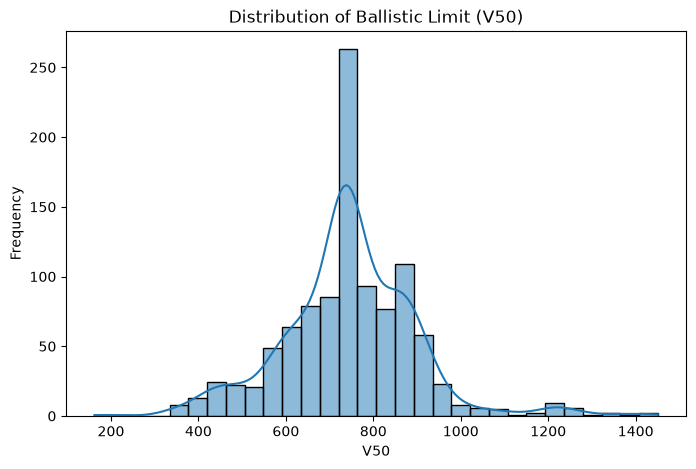

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["v50"], bins=30, kde=True)

plt.title("Distribution of Ballistic Limit (V50)")
plt.xlabel("V50")
plt.ylabel("Frequency")

plt.show()

In [31]:
print(df_clean["v50"].describe())

count    1033.000000
mean      745.126815
std       154.356135
min       162.000000
25%       664.000000
50%       739.000000
75%       837.000000
max      1451.000000
Name: v50, dtype: float64


### Observation

- The ballistic limit (V50) ranges from **162 m/s** to **1451 m/s**, indicating a wide variation in ballistic performance across different projectile-material combinations.
- The average V50 is approximately **745.13 m/s**, with a median value of **739 m/s**, suggesting that the data is centered around this range.
- The distribution is **approximately bell-shaped with a slight right (positive) skew**, as a few observations have considerably higher V50 values than the majority of the dataset.
- Most observations are concentrated between **600 m/s and 900 m/s**, indicating that this range represents the typical ballistic limit for the experiments.
- Overall, the target variable is reasonably distributed for regression analysis, although a few high-value observations may require further investigation during outlier analysis.

### 3.2 Box Plot of V50

A box plot is used to identify potential outliers in the target variable. Extreme observations may influence model performance and should be examined before training.

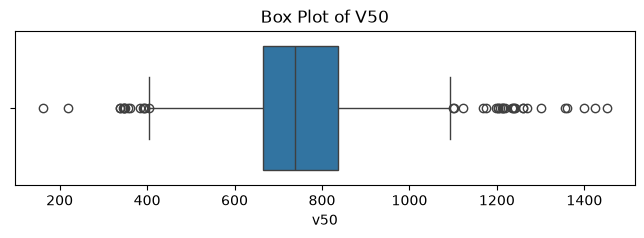

In [32]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df_clean["v50"])

plt.title("Box Plot of V50")

plt.show()

### Observation

- The box plot indicates the presence of **outliers on both the lower and upper ends** of the V50 distribution.
- Most observations are concentrated between approximately **664 m/s (Q1)** and **837 m/s (Q3)**, with a median of **739 m/s**.
- A few experiments exhibit exceptionally **low** and **high** ballistic limit values compared to the majority of the dataset.
- These outliers are **likely to represent valid experimental observations** arising from different projectile types, armor materials, and impact conditions rather than data entry errors.
- Therefore, the outliers will **be retained** in the dataset, as they contain valuable information for developing a robust machine learning model.

### 3.3 Correlation Analysis

Correlation analysis is performed to measure the strength of linear relationships between numerical features. Features with strong correlations to the target variable may have greater predictive importance.

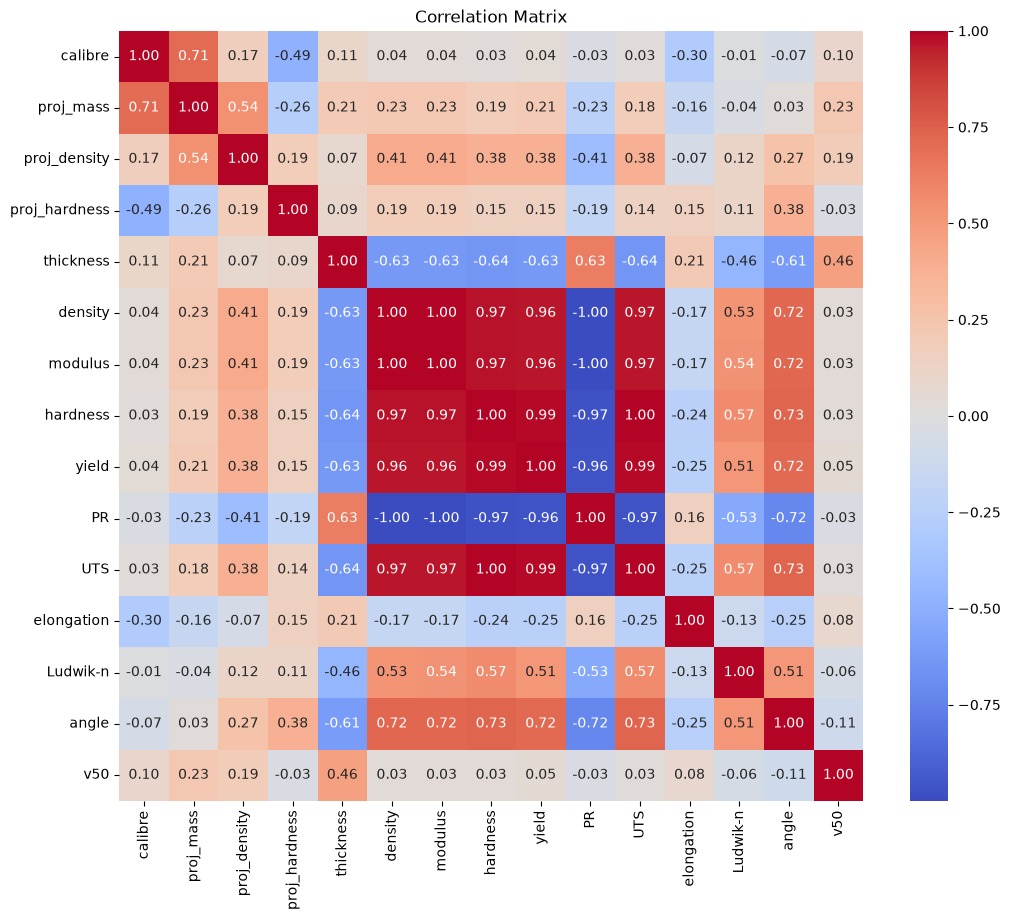

In [33]:
numeric_df = df_clean.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

- The correlation matrix shows that **no single numerical feature has a very strong linear correlation with the target variable (V50)**.
- Among the numerical features, **thickness** exhibits the highest positive correlation with **V50 (≈ 0.46)**, indicating that thicker armor plates generally provide higher ballistic resistance.
- Most material properties such as **density, modulus, hardness, yield strength, and UTS** show only weak individual correlations with V50, suggesting that ballistic performance is influenced by the combined effect of multiple variables rather than any single property.
- Several material-related features are **highly correlated with one another**, indicating the presence of multicollinearity. For example, hardness, yield strength, and UTS exhibit very strong positive correlations.
- These observations suggest that **non-linear machine learning models** such as Random Forest and XGBoost are likely to capture the complex relationships in the data more effectively than simple linear regression models.

### 3.4 Relationship Between Armor Thickness and Ballistic Limit

Armor thickness is expected to have a significant influence on ballistic performance. A scatter plot is used to visualize the relationship between armor thickness and the ballistic limit (V50).

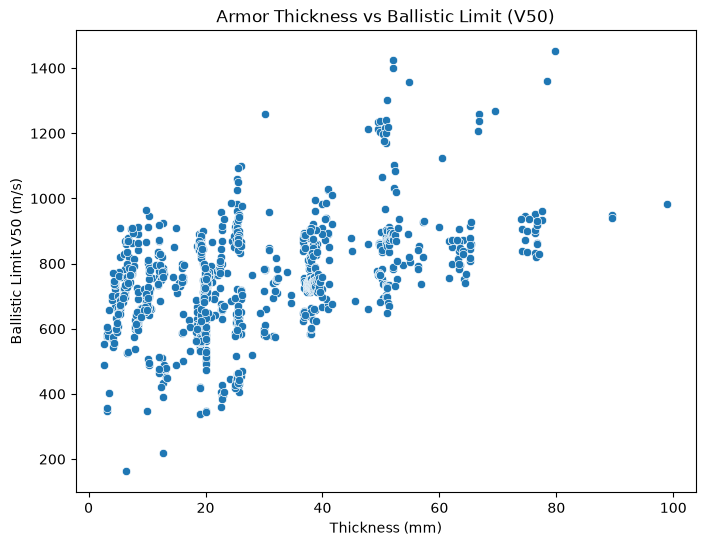

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="thickness",
    y="v50"
)

plt.title("Armor Thickness vs Ballistic Limit (V50)")
plt.xlabel("Thickness (mm)")
plt.ylabel("Ballistic Limit V50 (m/s)")

plt.show()

### Observation

- The scatter plot indicates a **moderate positive relationship** between armor thickness and the ballistic limit (V50).
- As the thickness of the armor plate increases, the V50 generally increases, suggesting improved ballistic resistance.
- The relationship is not strictly linear, as considerable variation in V50 exists for the same thickness values. This indicates that ballistic performance is also influenced by factors such as material properties, projectile characteristics, and impact conditions.
- The vertical clusters observed in the plot correspond to commonly tested armor thicknesses used in ballistic experiments.
- Overall, armor thickness appears to be one of the most influential features affecting the ballistic limit.

### 3.5 Average Ballistic Limit Across Different Armor Materials

Different armor materials possess different mechanical properties, which directly influence their ballistic performance. This analysis compares the average V50 achieved by each material to identify high-performing armor materials.

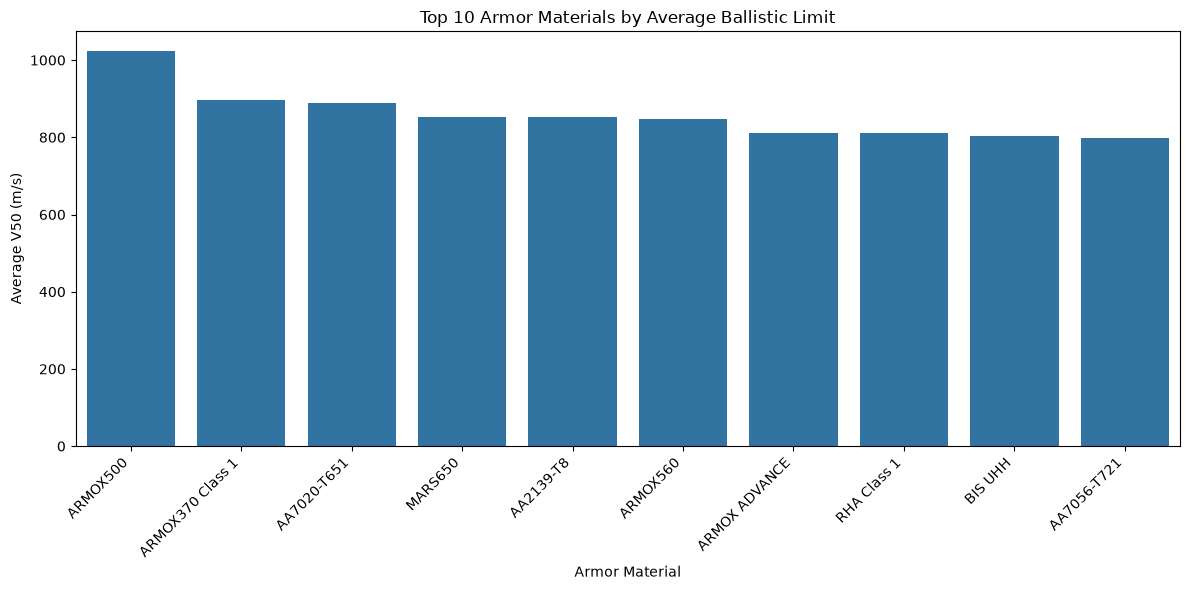

Material
ARMOX500            1023.375000
ARMOX370 Class 1     896.529412
AA7020-T651          890.000000
MARS650              853.857143
AA2139-T8            851.952381
ARMOX560             848.333333
ARMOX ADVANCE        810.375000
RHA Class 1          810.000000
BIS UHH              804.333333
AA7056-T721          799.000000
Name: v50, dtype: float64

In [35]:
material_avg = (
    df_clean.groupby("Material")["v50"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=material_avg.index,
    y=material_avg.values
)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Armor Material")
plt.ylabel("Average V50 (m/s)")
plt.title("Top 10 Armor Materials by Average Ballistic Limit")

plt.tight_layout()
plt.show()

material_avg

### Observation

- The average ballistic limit (V50) varies significantly across different armor materials, indicating that material selection plays a crucial role in ballistic performance.
- **ARMOX500** exhibits the highest average ballistic limit (approximately **1023 m/s**), suggesting superior resistance against projectile penetration among the materials considered.
- High-strength steel grades such as **ARMOX370 Class 1**, **ARMOX560**, and **ARMOX ADVANCE** also demonstrate excellent ballistic performance.
- Certain aluminium alloys, including **AA7020-T651** and **AA2139-T8**, achieve relatively high V50 values despite having lower density than steel, highlighting the effectiveness of advanced lightweight armor materials.
- These results indicate that the **Material** feature is expected to be an important predictor in the machine learning model.

In [36]:
sorted(df_clean["Material"].unique())

['AA2024-T351',
 'AA2060-T8',
 'AA2139-T8',
 'AA5059-H131',
 'AA5059-H136',
 'AA5083-H112',
 'AA5083-H116',
 'AA5083-H131',
 'AA6055-T651',
 'AA6061-T651',
 'AA6070-O',
 'AA6070-T4',
 'AA6070-T6',
 'AA6070-T7',
 'AA6082-T6',
 'AA7017-T6',
 'AA7017-T7',
 'AA7020-T651',
 'AA7039-T64',
 'AA7056-T721',
 'AA7056-T751',
 'AA7056-T761',
 'AA7075-T651',
 'AA7085-T711',
 'AA7085-T721',
 'ARMOX ADVANCE',
 'ARMOX370 Class 1',
 'ARMOX500',
 'ARMOX560',
 'ARMOX600',
 'ATI 500-MIL',
 'BIS HHA',
 'BIS HTA',
 'BIS RHA300',
 'BIS RHA360',
 'BIS UHH',
 'BIS UHTA',
 'HHA Class 1',
 'MARS440',
 'MARS500',
 'MARS600',
 'MARS650',
 'RHA Class 1',
 'SECURE350',
 'SECURE400',
 'SECURE500',
 'SECURE600']

In [37]:
print(df_clean["Material"].str.contains("Ti", case=False).sum())

10


In [38]:
df_clean[df_clean["Material"].str.contains("Ti", case=False)]

,projectile,proj_type,calibre,proj_mass,proj_density,proj_hardness,Material,thickness,density,modulus,hardness,yield,PR,UTS,elongation,Ludwik-n,angle,v50
465,CAL30APM2,AP,6.2484,5.3,7.85,570,ATI 500-MIL,5.1,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,663
466,CAL30APM2,AP,6.2484,5.3,7.85,570,ATI 500-MIL,6.9,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,819
467,CAL30APM2,AP,6.2484,5.3,7.85,570,ATI 500-MIL,7.7,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,814
468,CAL50APM2,AP,10.8839,25.9,7.85,630,ATI 500-MIL,7.9,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,627
469,CAL50APM2,AP,10.8839,25.9,7.85,630,ATI 500-MIL,9.5,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,723
470,CAL50APM2,AP,10.8839,25.9,7.85,630,ATI 500-MIL,12.7,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,787
471,145MMB32,AP,12.4206,41.1,7.85,595,ATI 500-MIL,15.6,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,730
472,145MMB32,AP,12.4206,41.1,7.85,595,ATI 500-MIL,15.4,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,739
473,145MMB32,AP,12.4206,41.1,7.85,595,ATI 500-MIL,18.8,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,841
474,145MMBS41,AP,10.9220,37.9,14.85,730,ATI 500-MIL,24.5,7.85,207.0,505.5,1792.0,0.3,1690.0,11.1,0.1175,30,869


### 3.6 Ballistic Limit Across Different Projectile Types

Projectile type significantly influences ballistic performance due to differences in geometry, hardness, and penetration mechanisms. This analysis compares the distribution of V50 values for different projectile categories to understand their effect on armor resistance.

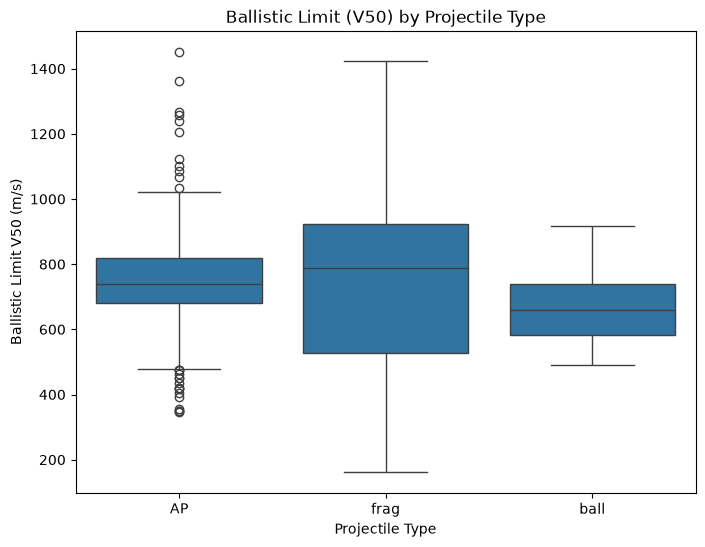

In [39]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x="proj_type",
    y="v50"
)

plt.title("Ballistic Limit (V50) by Projectile Type")
plt.xlabel("Projectile Type")
plt.ylabel("Ballistic Limit V50 (m/s)")

plt.show()

In [40]:
df_clean.groupby("proj_type")["v50"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
proj_type,,,,,,,,
AP,855.0,744.10,122.08,347.0,682.0,738.0,819.0,1451.0
ball,19.0,671.84,116.55,490.0,582.0,659.0,739.0,918.0
frag,159.0,759.38,269.57,162.0,526.0,787.0,922.5,1425.0


### 3.7 Relationship Between Projectile Mass and Ballistic Limit

Projectile mass influences the kinetic energy and momentum of the projectile, making it an important factor in determining the ballistic limit. A scatter plot is used to examine the relationship between projectile mass and V50.

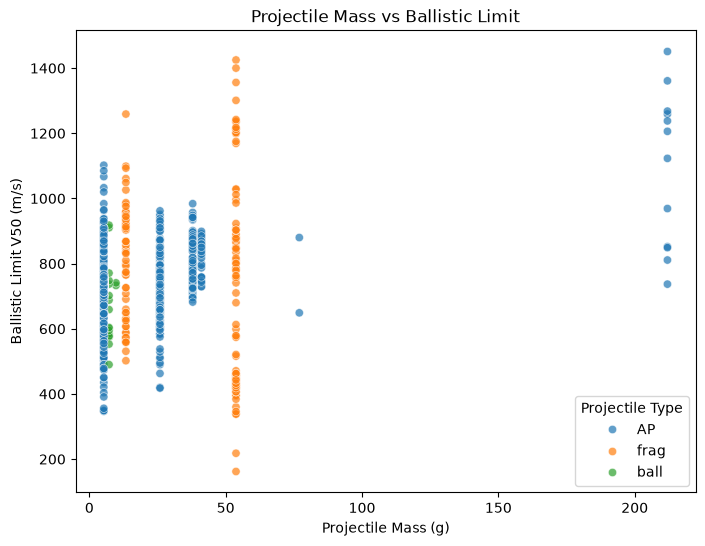

In [41]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="proj_mass",
    y="v50",
    hue="proj_type",
    alpha=0.7
)

plt.title("Projectile Mass vs Ballistic Limit")
plt.xlabel("Projectile Mass (g)")
plt.ylabel("Ballistic Limit V50 (m/s)")

plt.legend(title="Projectile Type")

plt.show()

### Observation

- The ballistic limit (V50) varies across different projectile types, indicating that projectile geometry and design significantly influence penetration behavior.
- **Fragment simulator (frag)** projectiles exhibit the **highest median V50 (~787 m/s)** and the largest variability, suggesting a wide range of ballistic responses under different experimental conditions.
- **Armor Piercing (AP)** projectiles have a median V50 of approximately **738 m/s** and exhibit several high-value outliers, reflecting their diverse experimental configurations.
- **Ball** projectiles show the lowest average ballistic limit (**≈671 m/s**) and the narrowest spread, indicating relatively consistent ballistic performance.
- These results demonstrate that **projectile type is an important categorical feature** and should be included in the predictive model.

### Observation

- The relationship between projectile mass and ballistic limit is **not purely linear**.
- Projectiles with similar masses exhibit a wide range of V50 values, indicating that ballistic performance depends on multiple interacting factors rather than projectile mass alone.
- The scatter plot suggests that projectile type and armor material significantly influence the observed ballistic limit for a given projectile mass.
- Several heavier projectiles achieve higher V50 values; however, considerable overlap exists across different mass ranges.
- These observations support the use of **non-linear machine learning algorithms**, which can capture complex interactions between projectile characteristics and material properties.

### 3.8 Comparison of Material Families

The dataset contains two major classes of armor materials: aluminium alloys and armor steels. Comparing their ballistic performance provides a broader understanding of how material family influences the ballistic limit.

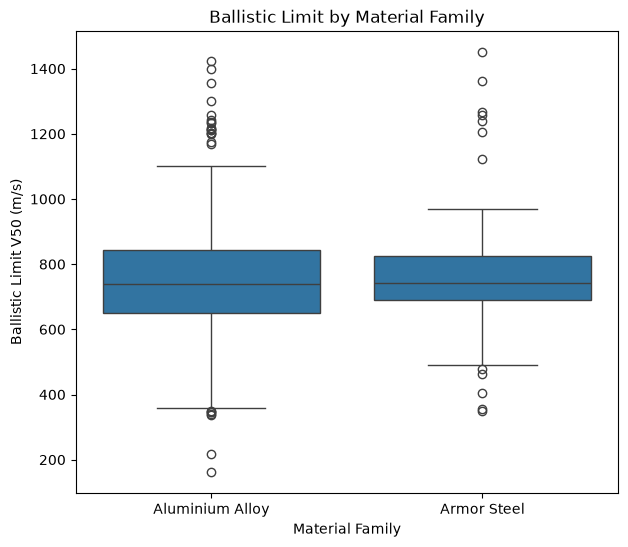

,count,mean,std,min,25%,50%,75%,max
Material_Family,,,,,,,,
Aluminium Alloy,670.0,741.58,167.56,162.0,650.0,738.0,844.5,1425.0
Armor Steel,363.0,751.68,126.37,349.0,689.5,742.0,826.0,1451.0


In [42]:
def material_family(material):
    if material.startswith("AA"):
        return "Aluminium Alloy"
    else:
        return "Armor Steel"

df_clean["Material_Family"] = df_clean["Material"].apply(material_family)

plt.figure(figsize=(7,6))

sns.boxplot(
    data=df_clean,
    x="Material_Family",
    y="v50"
)

plt.title("Ballistic Limit by Material Family")
plt.xlabel("Material Family")
plt.ylabel("Ballistic Limit V50 (m/s)")

plt.show()

df_clean.groupby("Material_Family")["v50"].describe().round(2)

### Observation

- The comparison between aluminium alloys and armor steels shows that both material families achieve comparable ballistic performance, although armor steels exhibit a slightly higher average V50.
- The average ballistic limit for **armor steels** is approximately **751.68 m/s**, compared to **741.58 m/s** for **aluminium alloys**.
- Armor steels display a smaller spread in V50 values, indicating more consistent ballistic performance across different steel grades.
- Aluminium alloys exhibit greater variability, reflecting the wide range of mechanical properties among different aluminium alloy compositions and heat treatments.
- Both material families contain high-performing materials capable of achieving V50 values exceeding **1400 m/s**, demonstrating that ballistic performance depends not only on the material family but also on factors such as thickness, projectile characteristics, and impact conditions.
- These findings suggest that the **Material** feature should be retained as an important predictor in the machine learning model.

## Step 3 Conclusion

The exploratory data analysis provided valuable insights into the factors influencing the ballistic limit (V50). Armor thickness demonstrated the strongest positive relationship with V50 among the numerical features, while categorical variables such as projectile type and material were also found to significantly influence ballistic performance. Although individual numerical features exhibited relatively weak linear correlations with the target variable, the analysis suggested that ballistic behavior is governed by complex interactions between projectile characteristics, material properties, and testing conditions. These findings support the use of non-linear machine learning models for accurate prediction of the ballistic limit.

In [43]:
print(sorted(df["Material"].unique()))

['AA2024-T351', 'AA2060-T8', 'AA2139-T8', 'AA5059-H131', 'AA5059-H136', 'AA5083-H112', 'AA5083-H116', 'AA5083-H131', 'AA6055-T651', 'AA6061-T651', 'AA6070-O', 'AA6070-T4', 'AA6070-T6', 'AA6070-T7', 'AA6082-T6', 'AA7017-T6', 'AA7017-T7', 'AA7020-T651', 'AA7039-T64', 'AA7056-T721', 'AA7056-T751', 'AA7056-T761', 'AA7075-T651', 'AA7085-T711', 'AA7085-T721', 'ARMOX ADVANCE', 'ARMOX370 Class 1', 'ARMOX500', 'ARMOX560', 'ARMOX600', 'ATI 500-MIL', 'BIS HHA', 'BIS HTA', 'BIS RHA300', 'BIS RHA360', 'BIS UHH', 'BIS UHTA', 'HHA Class 1', 'MARS440', 'MARS500', 'MARS600', 'MARS650', 'RHA Class 1', 'SECURE350', 'SECURE400', 'SECURE500', 'SECURE600']
